<div style="font-size: 60px;">
📖 Analysez les ventes d'une librairie
</div>

<div style="font-size: 42px;">
📐 Analyse en Composantes Principales
</div>

# Import des librairies et paramètres généraux

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
data_path = "../data/"

# Chargement des données préparées

In [4]:
df_merge = pd.read_csv(data_path + "processed/merge.csv", dtype = "str")
df_merge

,id_prod,price,categ,date,session_id,client_id,sex,birth,age,client_type
0,0_0,3.75,0,2021-03-02 21:57:33.862118,s_908,c_1004,m,1973,49,B2C
1,0_0,3.75,0,2022-02-18 16:40:10.068303,s_167174,c_1011,f,1999,24,B2C
2,0_0,3.75,0,2022-03-18 16:40:10.068303,s_180968,c_1011,f,1999,24,B2C
3,0_0,3.75,0,2022-04-18 16:40:10.068303,s_195932,c_1011,f,1999,24,B2C
4,0_0,3.75,0,2023-02-18 16:40:10.068303,s_343439,c_1011,f,1999,25,B2C
...,...,...,...,...,...,...,...,...,...,...
687529,2_99,84.99,2,2022-07-21 01:53:46.967570,s_241374,c_5828,f,1998,25,B2C
687530,2_99,84.99,2,2023-01-21 01:53:46.967570,s_329932,c_5828,f,1998,26,B2C
687531,2_99,84.99,2,2021-07-11 20:56:49.820935,s_61009,c_7135,m,1996,26,B2C
687532,2_99,84.99,2,2022-11-11 20:56:49.820935,s_296127,c_7135,m,1996,27,B2C


In [5]:
df_merge["price"] = df_merge["price"].astype(float)
df_merge["birth"] = df_merge["birth"].astype(int)
df_merge["age"] = df_merge["age"].astype(int)
df_merge["date"] = pd.to_datetime(df_merge["date"])
df_merge.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   id_prod      687534 non-null  object        
 1   price        687534 non-null  float64       
 2   categ        687534 non-null  object        
 3   date         687534 non-null  datetime64[ns]
 4   session_id   687534 non-null  object        
 5   client_id    687534 non-null  object        
 6   sex          687534 non-null  object        
 7   birth        687534 non-null  int64         
 8   age          687534 non-null  int64         
 9   client_type  687534 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 52.5+ MB


In [6]:
df_merge_b2c = df_merge[ (df_merge["client_type"] == "B2C") ]
df_merge_b2b = df_merge[ (df_merge["client_type"] == "B2B") ]

# Sélection de données quantitatives

In [7]:
df_pca = df_merge_b2c.groupby("client_id").agg({
    "age":["mean"],
    # "sex":["first"],
    "session_id":["nunique"],
    # "price":["count","sum"],
})
df_pca.columns = [
    "age",
    # "sex",
    "nb_sessions",
    # "freq_total", "amount_total",
]

# df_pca["sex"] = df_pca["sex"].map("mf".index)

df_pca_tmp = df_merge_b2c.groupby(["client_id","categ"]).size().unstack(fill_value=0)
df_pca_tmp.columns = [ f"freq_categ_{categ}" for categ in df_pca_tmp.columns ]
df_pca = df_pca.join(df_pca_tmp)

df_pca_tmp = df_merge_b2c.groupby(["client_id","categ"])["price"].sum().unstack(fill_value=0)
df_pca_tmp.columns = [ f"amount_categ_{categ}" for categ in df_pca_tmp.columns ]
df_pca = df_pca.join(df_pca_tmp)

del df_pca_tmp
df_pca.columns.name = "features"
df_pca

features,age,nb_sessions,freq_categ_0,freq_categ_1,freq_categ_2,amount_categ_0,amount_categ_1,amount_categ_2
client_id,,,,,,,,
c_1,67.511628,34,30,12,1,360.15,214.00,54.87
c_10,66.603448,34,20,34,4,263.87,809.77,279.96
c_100,30.250000,5,2,5,1,31.38,84.94,138.53
c_1000,56.714286,94,43,83,0,386.85,1905.03,0.00
c_1001,40.611650,47,70,32,1,907.73,616.12,300.00
...,...,...,...,...,...,...,...,...
c_995,67.428571,9,11,3,0,125.67,63.74,0.00
c_996,52.656250,80,40,56,0,485.77,1151.57,0.00
c_997,28.762712,24,23,21,15,207.28,471.75,810.98


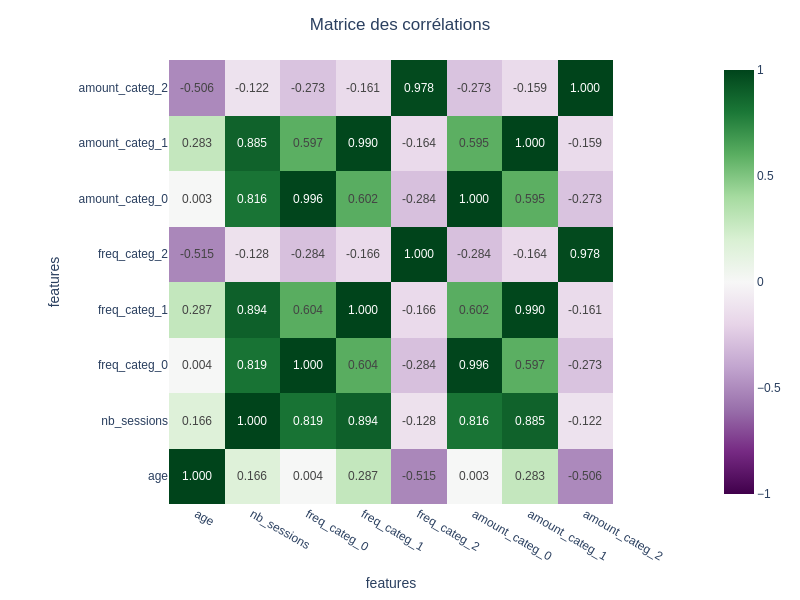

In [8]:
img = df_pca.corr()
# m, n = img.shape
# assert m == n
# img = pd.DataFrame(np.where(np.tri(n, k=0, dtype=int), img, 0), index=img.index, columns=img.columns)
fig = px.imshow(img, range_color=(-1,1), color_continuous_scale="PRGn", aspect="equal", text_auto=".3f", origin="lower")
fig.update_layout(title="Matrice des corrélations", title_x=0.5, width=800, height=600)
fig.show(renderer="png")

In [9]:
df_pca.describe()

features,age,nb_sessions,freq_categ_0,freq_categ_1,freq_categ_2,amount_categ_0,amount_categ_1,amount_categ_2
count,8596.000000,8596.000000,8596.000000,8596.000000,8596.000000,8596.000000,8596.000000,8596.000000
mean,44.381997,37.513495,45.053630,25.663681,3.821312,479.199708,525.837815,291.305777
std,16.913830,30.898817,55.234935,20.806135,7.790909,589.021307,431.704598,597.309727
min,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.571429,15.000000,9.000000,10.000000,0.000000,89.395000,206.835000,0.000000
50%,43.484360,27.000000,25.000000,20.000000,0.000000,263.865000,399.410000,0.000000
75%,56.545455,50.000000,56.000000,35.000000,3.000000,601.517500,731.475000,243.600000
max,93.897959,167.000000,316.000000,150.000000,61.000000,3634.160000,3161.290000,4409.660000


# Normalisation des variables

In [10]:
df_pca_std = pd.DataFrame(StandardScaler().fit_transform(df_pca), index=df_pca.index, columns=df_pca.columns)
df_pca_std.describe().loc[["mean","std"]].round(3)

features,age,nb_sessions,freq_categ_0,freq_categ_1,freq_categ_2,amount_categ_0,amount_categ_1,amount_categ_2
mean,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


# Analyse en Composantes Principales

## Calcul des composantes principales

In [11]:
pca = PCA()
pca

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [12]:
pc_coordinates = pca.fit_transform(df_pca_std)
pca

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [13]:
df_pc_coordinates = pd.DataFrame(pc_coordinates, columns=[ f"PC{i+1}" for i in range(df_pca.columns.size) ], index=df_pca.index)
df_pc_coordinates.columns.name = "PC"
df_pc_coordinates

PC,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
client_id,,,,,,,,
c_1,-0.452113,-1.321014,0.295484,1.044687,0.328059,0.020001,0.007617,-0.055768
c_10,0.259827,-0.539860,1.445597,0.324717,-0.295751,0.058700,-0.156107,-0.057074
c_100,-1.947604,-0.700456,-0.739226,-0.611599,0.055077,-0.097119,0.022731,-0.014494
c_1000,3.543574,0.323616,2.616577,-1.604137,0.069920,-0.024416,-0.298607,0.071764
c_1001,0.876295,0.173910,-0.474278,-0.038555,-0.108046,-0.258289,0.071350,-0.192745
...,...,...,...,...,...,...,...,...
c_995,-1.399001,-1.821967,0.218312,0.966819,0.008635,0.011690,-0.022943,-0.009212
c_996,2.076561,-0.091325,1.288439,-0.788020,0.482113,-0.044072,-0.026145,-0.089161
c_997,-1.322655,1.513348,0.125905,-0.212850,-0.171185,0.405485,-0.042061,0.049453


In [14]:
df_join = df_pca.join(df_pc_coordinates)
df_join.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 8596 entries, c_1 to c_999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             8596 non-null   float64
 1   nb_sessions     8596 non-null   int64  
 2   freq_categ_0    8596 non-null   int64  
 3   freq_categ_1    8596 non-null   int64  
 4   freq_categ_2    8596 non-null   int64  
 5   amount_categ_0  8596 non-null   float64
 6   amount_categ_1  8596 non-null   float64
 7   amount_categ_2  8596 non-null   float64
 8   PC1             8596 non-null   float64
 9   PC2             8596 non-null   float64
 10  PC3             8596 non-null   float64
 11  PC4             8596 non-null   float64
 12  PC5             8596 non-null   float64
 13  PC6             8596 non-null   float64
 14  PC7             8596 non-null   float64
 15  PC8             8596 non-null   float64
dtypes: float64(12), int64(4)
memory usage: 1.1+ MB


In [15]:
df_components = pd.DataFrame(pca.components_, columns=df_pca.columns, index=df_pc_coordinates.columns)
df_components

features,age,nb_sessions,freq_categ_0,freq_categ_1,freq_categ_2,amount_categ_0,amount_categ_1,amount_categ_2
PC,,,,,,,,
PC1,0.156441,0.443413,0.412670,0.420556,-0.210878,0.412023,0.417985,-0.206888
PC2,-0.434289,0.211028,0.121841,0.143674,0.589503,0.121434,0.143716,0.590304
PC3,0.547815,0.076360,-0.421961,0.363995,0.186249,-0.423324,0.367556,0.185836
PC4,0.694077,0.058475,0.292829,-0.310350,0.248310,0.295511,-0.328094,0.275939
PC5,-0.068783,0.860348,-0.203879,-0.197995,-0.022444,-0.240136,-0.319599,-0.118276
PC6,0.018317,-0.054737,0.018826,-0.002497,0.714801,0.025122,0.026641,-0.695720
PC7,-0.001366,-0.076523,0.005349,0.730963,0.014429,0.022714,-0.677522,-0.006793
PC8,0.002671,-0.023476,0.713518,0.012873,0.004155,-0.700106,-0.001216,0.000121


## Variance expliquée par chaque composante principale

In [16]:
df_variance = pd.DataFrame(
    [ pca.explained_variance_, pca.explained_variance_ratio_ ],
    index=["variance","variance_pct"],
    columns = df_pc_coordinates.columns,
).T
df_variance["variance_pct_cumsum"] = np.cumsum(df_variance["variance_pct"])
df_variance["base"] = df_variance["variance_pct_cumsum"] - df_variance["variance_pct"]
df_variance

,variance,variance_pct,variance_pct_cumsum,base
PC,,,,
PC1,4.379049,0.547317,0.547317,0.000000
PC2,2.115745,0.264437,0.811755,0.547317
PC3,1.051609,0.131436,0.943191,0.811755
PC4,0.369628,0.046198,0.989389,0.943191
PC5,0.050515,0.006314,0.995703,0.989389
PC6,0.021204,0.002650,0.998353,0.995703
PC7,0.009395,0.001174,0.999527,0.998353
PC8,0.003785,0.000473,1.000000,0.999527


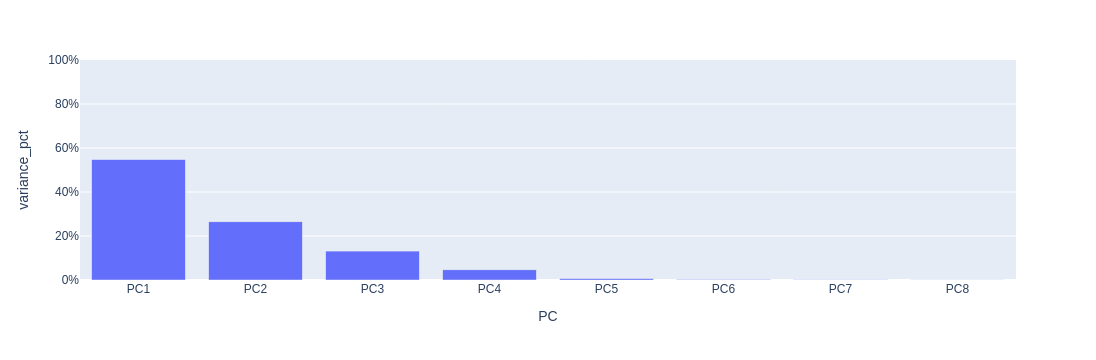

In [17]:
fig = px.bar(df_variance, x=df_variance.index, y="variance_pct", hover_data={"variance_pct":":.2%"})
fig.update_layout(yaxis=dict(range=(0,1), tickformat=".0%"))
fig.show()

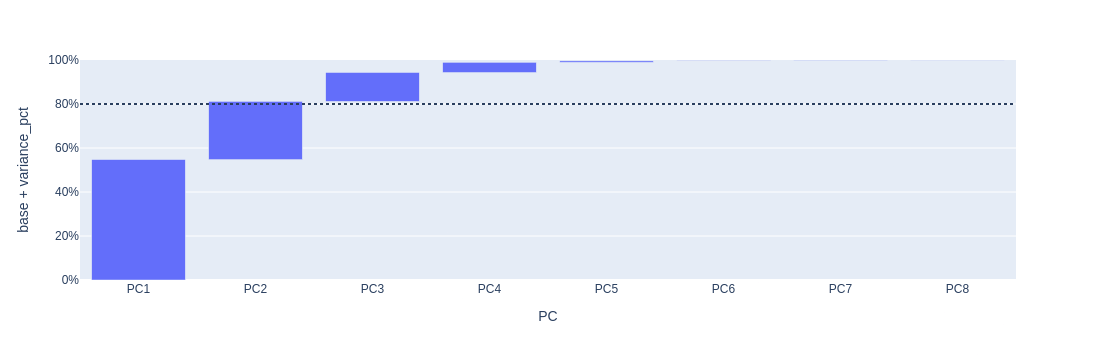

In [18]:
fig = px.bar(
    df_variance, x=df_variance.index, y="variance_pct", base="base",
    hover_data={"variance_pct":":.2%","base":False}, labels={"variance_pct":"base + variance_pct"},
)
fig.add_hline(y=0.80, line_dash="dot")
fig.update_layout(yaxis=dict(range=(0,1), tickformat=".0%"))
fig.show()

# Projection 2D

In [19]:
labels = { ind:f"{ind} ({var_pct:.2%})" for ind, var_pct in df_variance["variance_pct"].items() }
labels

{'PC1': 'PC1 (54.73%)',
 'PC2': 'PC2 (26.44%)',
 'PC3': 'PC3 (13.14%)',
 'PC4': 'PC4 (4.62%)',
 'PC5': 'PC5 (0.63%)',
 'PC6': 'PC6 (0.27%)',
 'PC7': 'PC7 (0.12%)',
 'PC8': 'PC8 (0.05%)'}

In [20]:
def acp_display_2d_combinations(n: int):
    assert n > 0, f"Illegal argument: n = {n}"
    fig = px.scatter_matrix(
        df_join, dimensions=[ f"PC{i+1}" for i in range(n) ], labels=labels,
        color=df_join["age"], color_continuous_scale="temps",
    )
    fig.update_traces(diagonal_visible=False, showupperhalf=False)
    fig.update_layout(width=1000, height=800, coloraxis_colorbar_title="age")
    fig.show(renderer="png")

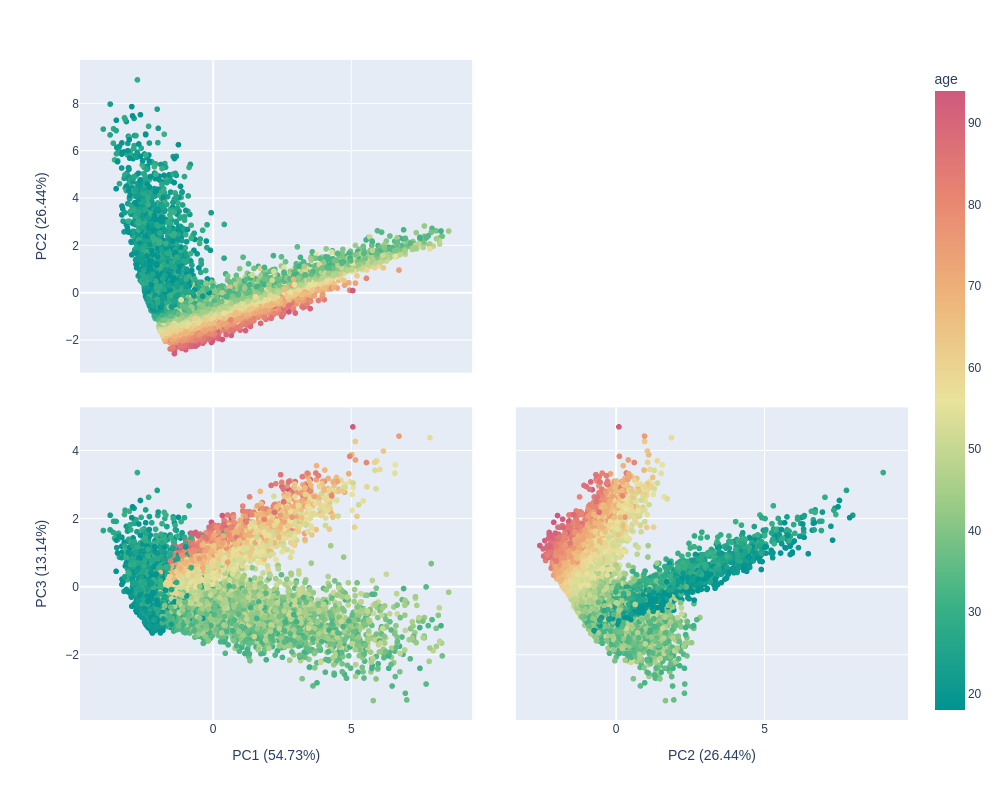

In [21]:
acp_display_2d_combinations(3)

In [22]:
def acp_display_2d(x: int, y: int, show_vectors: bool = False):
    assert x in range(1, df_pca.shape[1]+1), "Illegal argument: x = {x}"
    assert y in range(1, df_pca.shape[1]+1), "Illegal argument: y = {y}"
    assert len({ x, y }) == 2, "Illegal argument combination: not distinct"
    x = f"PC{x}"
    y = f"PC{y}"
    fig = px.scatter(
        df_join, x=x, y=y, labels=labels, hover_name=df_join.index, hover_data=df_pca.columns,
        color="age", color_continuous_scale="temps",
    )
    fig.update_layout(
        title=f"Projection 2D (variance expliquée = {df_variance.loc[[x,y],'variance_pct'].sum():.2%})",
        title_x=0.5, width=1000, height=600,
    )
    if show_vectors:
        loadings = df_components.loc[[x,y]].T * np.sqrt(df_variance.loc[[x,y],"variance"])
        for feature in df_pca.columns:
            fig.update_traces(opacity=0.10)
            fig.add_annotation(
                ax=0, ay=0,
                axref="x", ayref="y",
                x=loadings.loc[feature,x],
                y=loadings.loc[feature,y],
                showarrow=True,
                arrowsize=2,
                arrowhead=2,
                xanchor="right",
                yanchor="top",
            )
            fig.add_annotation(
                x=loadings.loc[feature,x],
                y=loadings.loc[feature,y],
                ax=0, ay=0,
                xanchor="center",
                yanchor="bottom",
                text=feature,
                yshift=5,
            )
    fig.show()

In [23]:
acp_display_2d(1, 2, True)

In [24]:
acp_display_2d(1, 3, True)

In [25]:
acp_display_2d(2, 3, True)

# Projection 3D

In [26]:
def acp_display_3d(x: int, y: int, z: int):
    assert x in range(1, df_pca.shape[1]+1), "Illegal argument: x = {x}"
    assert y in range(1, df_pca.shape[1]+1), "Illegal argument: y = {y}"
    assert z in range(1, df_pca.shape[1]+1), "Illegal argument: z = {z}"
    assert len({ x, y, z }) == 3, "Illegal argument combination: not distinct"
    x = f"PC{x}"
    y = f"PC{y}"
    z = f"PC{z}"
    fig = px.scatter_3d(
        df_join, x=x, y=y, z=z, labels=labels, hover_name=df_join.index, hover_data=df_pca.columns,
        color="age", color_continuous_scale="temps",
    )
    fig.update_layout(
        title=f"Projection 3D (variance expliquée = {df_variance.loc[[x,y,z],'variance_pct'].sum():.2%})",
        title_x=0.5, width=1000, height=800,
    )
    fig.update_traces(marker=dict(size=2))
    fig.show()

In [27]:
acp_display_3d(1, 2, 3)